In [0]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

%matplotlib inline

In [2]:
from google.colab import drive
drive.mount('/content/gdrive')
os.environ['KAGGLE_CONFIG_DIR'] = "/content/gdrive/My Drive/Kaggle"
%cd /content/gdrive/My Drive/Kaggle/Handwritten digits

Go to this URL in a browser: https://accounts.google.com/o/oauth2/auth?client_id=947318989803-6bn6qk8qdgf4n4g3pfee6491hc0brc4i.apps.googleusercontent.com&redirect_uri=urn%3aietf%3awg%3aoauth%3a2.0%3aoob&response_type=code&scope=email%20https%3a%2f%2fwww.googleapis.com%2fauth%2fdocs.test%20https%3a%2f%2fwww.googleapis.com%2fauth%2fdrive%20https%3a%2f%2fwww.googleapis.com%2fauth%2fdrive.photos.readonly%20https%3a%2f%2fwww.googleapis.com%2fauth%2fpeopleapi.readonly

Enter your authorization code:
··········
Mounted at /content/gdrive
/content/gdrive/My Drive/Kaggle/Handwritten digits


In [15]:
!kaggle competitions download -c digit-recognizer
!unzip \*.zip  && rm *.zip

  0% 0.00/235k [00:00<?, ?B/s]
100% 235k/235k [00:00<00:00, 15.5MB/s]
  0% 0.00/6.09M [00:00<?, ?B/s]
100% 6.09M/6.09M [00:00<00:00, 98.4MB/s]
  0% 0.00/9.16M [00:00<?, ?B/s]
100% 9.16M/9.16M [00:00<00:00, 84.3MB/s]
Archive:  test.csv.zip
  inflating: test.csv                

Archive:  train.csv.zip
  inflating: train.csv               

2 archives were successfully processed.


In [0]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

In [0]:
# Separating images from labels
X_train = train.drop(['label'], axis=1)
Y_train = train['label']

X_train = X_train.values.reshape(-1,28, 28,1)
test = test.values.reshape(-1,28, 28,1)

In [0]:
# Normalization
X_train = X_train.astype('float32')
test = test.astype('float32')

X_train = X_train / 255.0
test = test / 255.0

In [6]:
# Label encoding
from keras.utils.np_utils import to_categorical
Y_train = to_categorical(Y_train, num_classes=10)

Using TensorFlow backend.


In [0]:
# Splitting the data
from sklearn.model_selection import train_test_split
X_train, X_val, Y_train, Y_val = train_test_split(X_train, Y_train, test_size=0.1, random_state=42)

In [0]:
from keras.layers import Conv2D, MaxPool2D,Flatten, Dense, Dropout, Activation
from keras.models import Sequential

# Create model
model = Sequential()
model.add(Conv2D(32, (3, 3), input_shape=(28,28,1)))
model.add(Activation('relu'))

model.add(Conv2D(32, (5, 5)))
model.add(Activation('relu'))
model.add(MaxPool2D(pool_size=(2,2)))

model.add(Conv2D(64, (3, 3)))
model.add(Activation('relu'))
model.add(MaxPool2D(pool_size=(2,2), strides=(2,2)))

model.add(Flatten())
model.add(Dense(256))
model.add(Activation('relu'))
model.add(Dropout(0.5))
model.add(Dense(10))
model.add(Activation('softmax'))

In [0]:
from keras.optimizers import RMSprop
optimizer = RMSprop(lr=0.001, rho=0.9, epsilon=1e-08, decay=0.0)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

In [20]:
history = model.fit(X_train, Y_train, epochs=10, batch_size=63, validation_data=(X_val,Y_val), verbose=2)

Train on 37800 samples, validate on 4200 samples
Epoch 1/10
 - 3s - loss: 0.2046 - accuracy: 0.9363 - val_loss: 0.0598 - val_accuracy: 0.9819
Epoch 2/10
 - 3s - loss: 0.0647 - accuracy: 0.9805 - val_loss: 0.0494 - val_accuracy: 0.9860
Epoch 3/10
 - 3s - loss: 0.0456 - accuracy: 0.9861 - val_loss: 0.0430 - val_accuracy: 0.9879
Epoch 4/10
 - 3s - loss: 0.0363 - accuracy: 0.9891 - val_loss: 0.0385 - val_accuracy: 0.9890
Epoch 5/10
 - 3s - loss: 0.0296 - accuracy: 0.9907 - val_loss: 0.0387 - val_accuracy: 0.9879
Epoch 6/10
 - 3s - loss: 0.0269 - accuracy: 0.9914 - val_loss: 0.0333 - val_accuracy: 0.9890
Epoch 7/10
 - 3s - loss: 0.0221 - accuracy: 0.9931 - val_loss: 0.0497 - val_accuracy: 0.9874
Epoch 8/10
 - 3s - loss: 0.0203 - accuracy: 0.9938 - val_loss: 0.0346 - val_accuracy: 0.9919
Epoch 9/10
 - 3s - loss: 0.0190 - accuracy: 0.9946 - val_loss: 0.0323 - val_accuracy: 0.9895
Epoch 10/10
 - 3s - loss: 0.0165 - accuracy: 0.9951 - val_loss: 0.0372 - val_accuracy: 0.9890


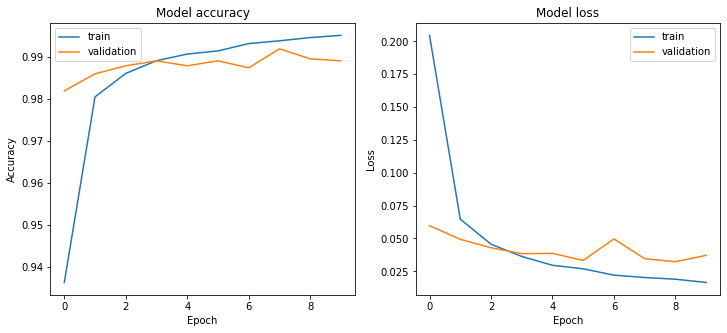

In [21]:
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(12,5))
ax1.plot(history.history['accuracy'])
ax1.plot(history.history['val_accuracy'])
ax1.legend(['train', 'validation'], loc='best')
ax1.set(xlabel='Epoch', ylabel='Accuracy')
ax1.set_title('Model accuracy');

ax2.plot(history.history['loss'])
ax2.plot(history.history['val_loss'])
ax2.legend(['train', 'validation'], loc='best')
ax2.set(xlabel='Epoch', ylabel='Loss')
ax2.set_title('Model loss');

In [0]:
model.save('keras.h5')

In [24]:
# Prepare the model for web format
!mkdir model
!tensorflowjs_converter --input_format keras keras.h5 model/

mkdir: cannot create directory ‘model’: File exists


In [25]:
# Download model
from google.colab import files
!zip -r model.zip model
files.download('model.zip')

  adding: model/ (stored 0%)
  adding: model/group1-shard1of1.bin (deflated 7%)
  adding: model/model.json (deflated 83%)
